# 01. 全体像と関数近似 — ニューラルネットは「関数を学ぶ機械」

> この教材の読み方: 各章は **直感 → 最小限の数式 → NumPy/PyTorch 実装 → 可視化 → 実験 → 演習** の順で進みます。
> 本文は日本語、コードは英語、数式の中には日本語を入れません。

## この章で分かること

- ニューラルネットワークとは結局「入力から出力への関数」であること
- 線形モデルでは解けない問題があり、**非線形性** と **深さ** が効くこと
- 隠れ層が入力空間を「ほぐして」分類しやすい表現に作り変えること

ニューラルネットを魔法の箱として扱わず、
**線形変換と非線形変換の合成でできた関数近似器** として最初から見ていきます。

```{admonition} 核心 — ひとことで
:class: tip
**ニューラルネットとは「アフィン変換と非線形活性化を交互に重ねた、学習可能な関数近似器」である。**
線形変換だけを重ねてもまた直線にしかならない。あいだに非線形 $\sigma$ を挟むと境界が曲がり、
ユニットを増やすほど任意の関数に近づける（万能近似）。隠れ層は入力を「線形分離できる表現」へほぐす。
```

## 1. ニューラルネットワークとは何か

ニューラルネットワークは、データから関数 $f_\theta: \mathbb{R}^{d} \to \mathbb{R}^{k}$ を学ぶ機械です。

- $\theta$ は **パラメータ**(重みとバイアス)
- 学習とは「データをうまく説明する $\theta$ を探す」こと

一番単純な構成要素は **アフィン変換**(線形変換 + 平行移動)です。

$$
z = W x + b
$$

ここで $W$ は重み行列、$b$ はバイアスベクトル。記号の意味:

- $x \in \mathbb{R}^{d}$: 入力ベクトル
- $W \in \mathbb{R}^{h \times d}$: 重み(入力をどう混ぜるか)
- $b \in \mathbb{R}^{h}$: バイアス(下駄)
- $z \in \mathbb{R}^{h}$: 出力

しかしアフィン変換をいくら重ねても、合成はまたアフィン変換にしかなりません。
ここに **非線形な活性化関数** $\sigma$ を挟むことで、はじめて表現力が跳ね上がります。

$$
f_\theta(x) = W_2\,\sigma(W_1 x + b_1) + b_2
$$

これが **多層パーセプトロン (MLP)** の最小形です。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nn_textbook import datasets, plotting
from nn_textbook.training import set_seed

set_seed(0)
np.set_printoptions(precision=3, suppress=True)

## 2. Problem — 線形モデルでは引けない境界

まず「線形分離できる」データと「できない」データを並べて見ます。
直線(線形モデル)で分けられるのはどちらでしょうか。

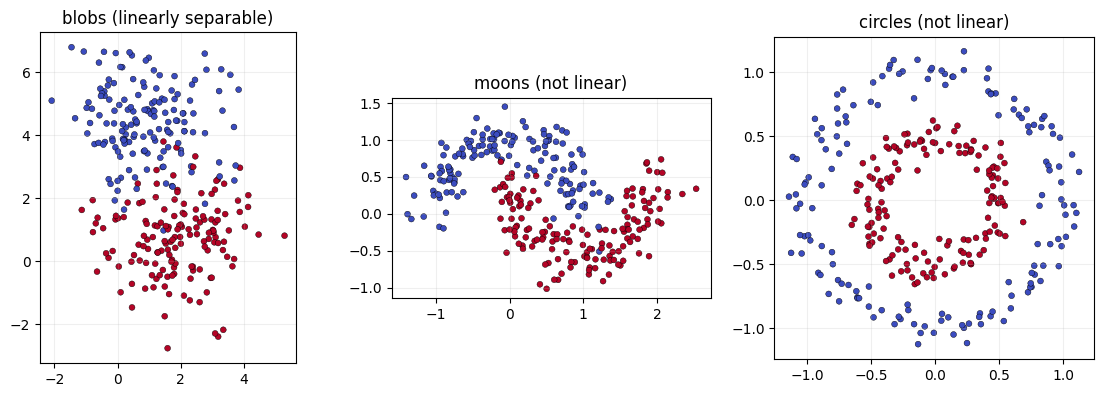

shapes: (300, 2) (300, 2) (300, 2)


In [2]:
# Three 2-D datasets with increasing nonlinearity.
Xb, yb = datasets.make_blobs_dataset(n=300, centers=2, cluster_std=1.2, seed=0)
Xm, ym = datasets.make_moons_dataset(n=300, noise=0.2, seed=0)
Xc, yc = datasets.make_circles_dataset(n=300, noise=0.08, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, (X, y, name) in zip(
    axes,
    [(Xb, yb, "blobs (linearly separable)"),
     (Xm, ym, "moons (not linear)"),
     (Xc, yc, "circles (not linear)")],
    strict=True,
):
    plotting.plot_2d_dataset(X, y, ax=ax, title=name)
plt.show()
print("shapes:", Xb.shape, Xm.shape, Xc.shape)

blobs は 1 本の直線で分けられますが、moons と circles は無理です。
これを **線形モデル(ロジスティック回帰)** で確かめます。

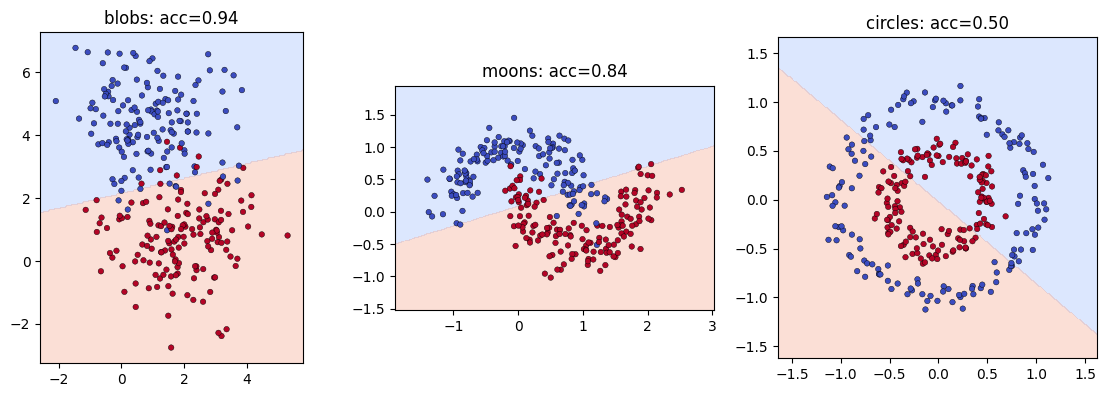

In [3]:
# A linear classifier draws a straight boundary; fine for blobs, hopeless for circles.
from sklearn.linear_model import LogisticRegression

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, (X, y, name) in zip(
    axes,
    [(Xb, yb, "blobs"), (Xm, ym, "moons"), (Xc, yc, "circles")],
    strict=True,
):
    clf = LogisticRegression().fit(X, y)
    acc = clf.score(X, y)
    plotting.plot_decision_boundary(clf.predict, X, y, ax=ax, title=f"{name}: acc={acc:.2f}")
plt.show()

circles では精度が 0.5 付近 — まったく分けられていません。
線形モデルの境界は必ず直線(高次元では超平面)で、曲がれないからです。

## 3. Intuition — 非線形活性化が空間を曲げる

ニューラルネットが曲がった境界を引ける秘密は、活性化関数の **非線形性** です。
代表的な 3 つを見ます。

- **ReLU**: $\max(0, x)$。負を 0 に切り落とす。今日の標準。
- **sigmoid**: $1/(1+e^{-x})$。出力を $(0, 1)$ に潰す。
- **tanh**: $\tanh(x)$。出力を $(-1, 1)$ に潰す。

破線は導関数(勾配)です。これが学習で「どれだけ更新するか」を決めます。
sigmoid/tanh は両端で導関数がほぼ 0 になる点に注目(後の章の「勾配消失」の伏線)。

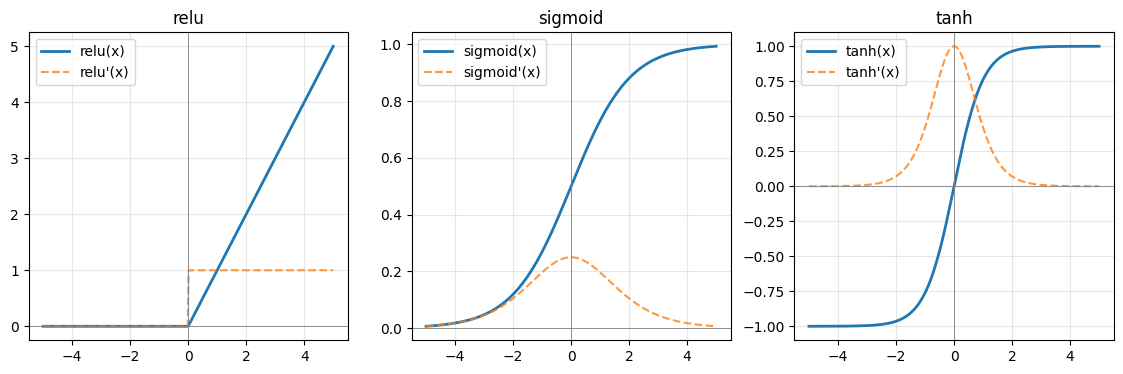

In [4]:
# Activation functions and their derivatives.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, ["relu", "sigmoid", "tanh"], strict=True):
    plotting.plot_activation_function(name, ax=ax)
    ax.set_title(name)
plt.show()

こちらは **静的 HTML でも動く** Plotly 版です。スライダーで活性化関数を切り替え、
関数（実線）と導関数（破線）を並べて確認できます。sigmoid/tanh が両端で導関数 ≈ 0 になる
（＝後の章の「勾配消失」の種）ことに注目してください。

In [5]:
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = plotting.plotly_activations()
fig.show()

### インタラクティブ: 活性化関数(JupyterLab のみ)

下のセルはスライダーで入力 $x$ を動かし、活性化の値と導関数を確認するデモです。
静的 HTML では動かないので、上の静的図と合わせて見てください。

In [6]:
# Interactive (JupyterLab only): move x and watch the activation value.
from nn_textbook.widgets import activation_explorer

activation_explorer()

interactive(children=(Dropdown(description='name', options=('relu', 'sigmoid', 'tanh'), value='relu'), FloatSl…

<function nn_textbook.widgets.activation_explorer.<locals>.draw(name, x0)>

## 4. Visualization — 関数近似デモ(1D 回帰)

「ニューラルネットは関数を学ぶ機械」を、一番見やすい 1 次元回帰で体感します。
ターゲットは $y = \sin(2\pi x)$。隠れ幅(ニューロン数)を変えると近似の表現力がどう変わるかを見ます。

ここでは共通モジュールの NumPy MLP(03 章で中身を自作します)を使います。

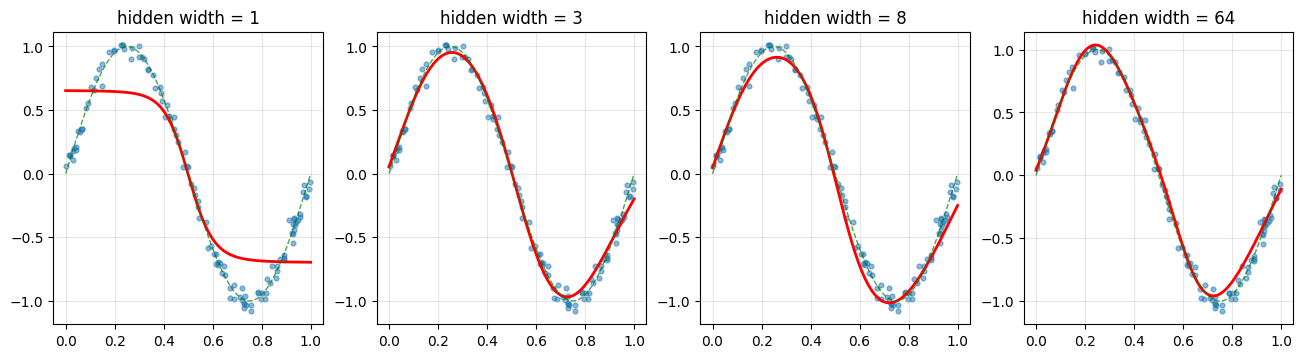

In [7]:
# Fit y = sin(2*pi*x) with MLPs of different hidden widths.
from nn_textbook.models import MLP
from nn_textbook.training import train_numpy_mlp

x, y = datasets.make_regression_1d(n=120, noise=0.05, seed=0)
xs = np.linspace(0, 1, 300, dtype=np.float32)[:, None]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, width in zip(axes, [1, 3, 8, 64], strict=True):
    model = MLP([1, width, width, 1], activation="tanh", task="regression", seed=0)
    train_numpy_mlp(model, x, y, lr=0.05, epochs=600, batch_size=32, seed=0)
    ax.scatter(x, y, s=12, alpha=0.5)
    ax.plot(xs, model.predict(xs), "r", lw=2)
    ax.plot(xs, np.sin(2 * np.pi * xs), "g--", lw=1, alpha=0.7)
    ax.set_title(f"hidden width = {width}")
    ax.grid(alpha=0.3)
plt.show()

### ▶ 触って確かめる — ユニット数を増やすと任意関数に近づく

上は幅を 4 段階で比べました。次は **ReLU ユニット数をスライダーで連続的に**増やし、ターゲット曲線への当てはまりを見ます。
ラベルの RMSE がユニット数とともに下がり、十分なユニットでほぼ完全に重なる — これが**万能近似定理**の体感版です。

In [8]:
# Universal approximation: more ReLU units -> closer fit (slider over unit count).
fig = plotting.plotly_function_approx()
fig.show()

幅 1 ではほぼ直線しか引けず、幅を増やすほど $\sin$ 曲線にフィットしていきます。
**ニューロンを増やす = 表現できる関数の自由度が増える**、という関数近似の直感です
(これを理論で裏打ちするのが Advanced Notes の「普遍近似定理」)。

## 5. Definition — 分類のための MLP

分類では、出力層に **softmax** をかけて確率にします。記号:

$$
\hat{p} = \mathrm{softmax}(W_2\,\sigma(W_1 x + b_1) + b_2), \qquad
\mathrm{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

- $\hat{p} \in \mathbb{R}^{k}$: 各クラスの予測確率(和が 1)
- 予測クラスは $\arg\max_i \hat{p}_i$

学習の目標は、正解クラスの確率を高くする $\theta$ を見つけることです
(損失関数の話は 03 章)。ここではまず「非線形 MLP なら moons/circles を分けられる」ことを確認します。

## 6. Computation — MLP で非線形境界を引く

線形モデルが失敗した 3 データに、隠れ層付き MLP を当てます。

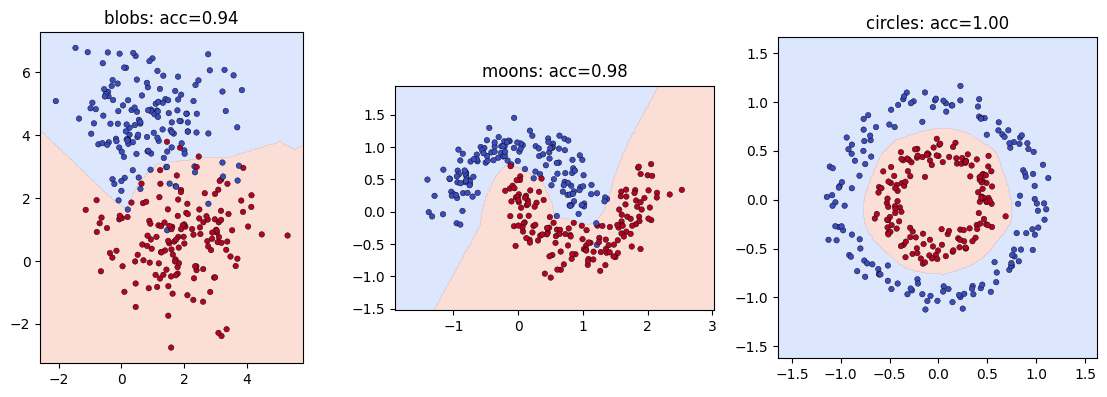

In [9]:
# A 2-hidden-layer MLP carves curved boundaries where the linear model failed.
from nn_textbook import metrics

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
models = {}
for ax, (X, y, name) in zip(
    axes,
    [(Xb, yb, "blobs"), (Xm, ym, "moons"), (Xc, yc, "circles")],
    strict=True,
):
    model = MLP([2, 32, 32, 2], activation="relu", seed=0)
    train_numpy_mlp(model, X, y, lr=0.3, epochs=300, batch_size=32, seed=0)
    acc = metrics.accuracy(model.predict(X), y)
    plotting.plot_decision_boundary(model.predict, X, y, ax=ax, title=f"{name}: acc={acc:.2f}")
    models[name] = (model, X, y)
plt.show()

今度は circles も moons も高精度。曲がった境界を引けています。

## 7. 隠れ層は空間を「ほぐす」

なぜ曲がった境界を引けるのか。答えは
**隠れ層が入力空間を、線形分離できる新しい表現に変形しているから** です。

circles のデータについて、最後の隠れ層(2 次元に絞った版)での表現を見てみます。
入力では同心円だったものが、隠れ表現では **直線で分けられる配置** にほぐれていれば成功です。

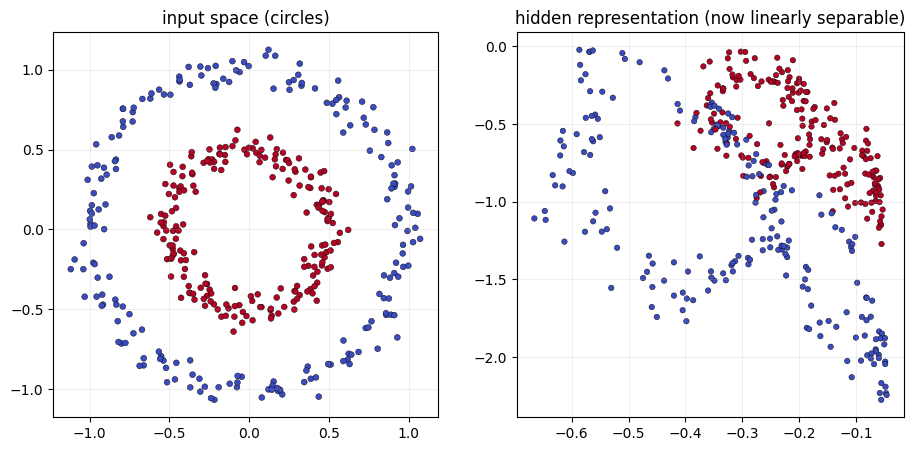

In [10]:
# Train an MLP whose last hidden layer is 2-D, so we can SEE the learned representation.
Xc2, yc2 = datasets.make_circles_dataset(n=400, noise=0.06, seed=0)
viz = MLP([2, 16, 2, 2], activation="relu", seed=0)   # ..., 2-dim hidden, 2 classes
train_numpy_mlp(viz, Xc2, yc2, lr=0.3, epochs=400, batch_size=32, seed=0)

H = viz.hidden_representation(Xc2, layer_index=-2)     # activations before the output layer

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plotting.plot_2d_dataset(Xc2, yc2, ax=axes[0], title="input space (circles)")
plotting.plot_hidden_representation(H, yc2, ax=axes[1],
                                    title="hidden representation (now linearly separable)")
plt.show()

入力では入れ子の円だった 2 クラスが、隠れ表現ではきれいに離れた 2 かたまりになります。
出力層がやることは、この **ほぐされた空間に 1 本の直線を引くだけ**。
「深層学習 = 表現学習」というスローガンの、最小にして本質的な実例です(08 章で深掘り)。

## 8. Failure Mode — 深さ・非線形がないとどうなるか

非線形を抜くと(活性化なし)、層を何枚重ねても線形モデルのままです。
moons で「線形のまま」になることを確認します。

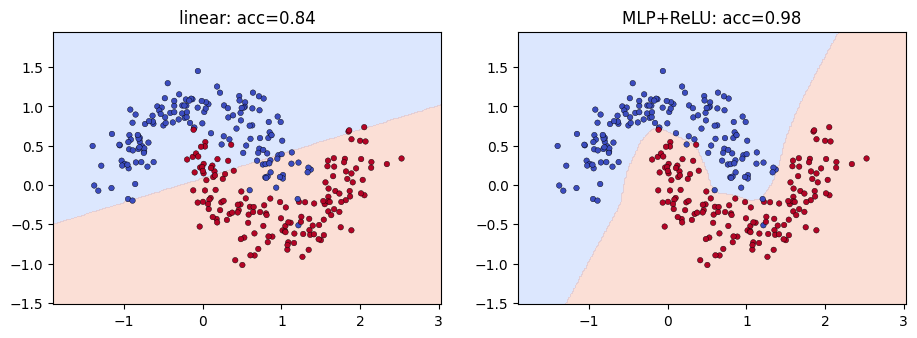

In [11]:
# Without nonlinearity, stacking layers stays linear: it cannot bend the boundary.
# We mimic 'no activation' by using a linear classifier on the moons data.
from sklearn.linear_model import LogisticRegression

linear = LogisticRegression().fit(Xm, ym)
nonlinear = MLP([2, 32, 32, 2], activation="relu", seed=0)
train_numpy_mlp(nonlinear, Xm, ym, lr=0.3, epochs=300, batch_size=32, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plotting.plot_decision_boundary(linear.predict, Xm, ym, ax=axes[0],
                                title=f"linear: acc={linear.score(Xm, ym):.2f}")
plotting.plot_decision_boundary(nonlinear.predict, Xm, ym, ax=axes[1],
                                title=f"MLP+ReLU: acc={metrics.accuracy(nonlinear.predict(Xm), ym):.2f}")
plt.show()

他の失敗の芽(後の章で扱う):

- 表現力が足りない(幅・深さ不足)→ **underfitting**(4 章)
- 表現力が過剰でノイズまで覚える → **overfitting**(4 章)
- 活性化が両端で潰れて勾配が消える → **勾配消失**(4 章)

## 9. Application — どこで使われているか

この「線形 + 非線形の合成で関数を近似する」枠組みは、すべての応用の土台です。

- 画像分類(05 章 CNN): ピクセル → クラス確率という関数
- 系列予測(06 章 RNN): 過去の系列 → 次の値という関数
- 言語モデル(07・10 章): トークン列 → 次トークン確率という関数

アーキテクチャが変わっても、**「微分可能な関数を勾配で最適化する」** という骨格は同じです。

```{admonition} 実社会では
:class: important
「線形＋非線形の合成を勾配で最適化する」枠組みが、現代 AI のほぼ全部の土台です。

- 画像認識・医療画像・自動運転：ピクセル → 物体／病変（CNN、05 章）。
- 言語：トークン列 → 次トークン（Transformer / LLM、07・10 章）。
- 音声・推薦・制御・科学：どれも「入力 → 出力」の微分可能な関数として学習。

アーキテクチャが変わっても骨格は不変 — だから 1 つの原理を押さえれば応用が一気に見通せます。
```

## 10. まとめ

- ニューラルネットワークは **アフィン変換と非線形活性化の合成** による関数近似器である。
- 線形モデルの境界は直線(超平面)のみ。**非線形性があって初めて境界が曲がる**。
- 幅・深さは表現力を決める。足りなければ表現できず、過剰ならノイズまで拾う(04 章)。
- 隠れ層は入力空間を **線形分離可能な表現へ変形する**。これが「表現学習」の最小例(08 章)。
- どんなアーキテクチャでも骨格は同じ:「微分可能な関数を勾配で最適化する」(02–03 章)。

## 11. Exercises

1. `make_blobs_dataset` の `cluster_std` を大きくして、線形モデルの精度がどう落ちるか調べよ。
2. 1D 回帰のターゲットを $\sin(2\pi x)$ から $\sin(4\pi x)$ に変え、
   同じ幅で近似できるか観察せよ。必要な幅はどう変わるか。
3. moons の `noise` を 0.05 / 0.2 / 0.4 と変え、MLP の決定境界の滑らかさを比較せよ。
4. circles を分ける MLP で、隠れ層を 1 枚に減らす / 幅を 4 に減らすと精度はどうなるか。
5. (発展)活性化を `relu` から `tanh` に変えて moons を学習し、境界の見た目の違いを述べよ。

## 12. Advanced Notes

**普遍近似定理 (Universal Approximation Theorem)。**
隠れ層が 1 層でも、ニューロン数を十分に増やせば、コンパクト集合上の任意の連続関数を
任意精度で近似できます(Cybenko 1989, Hornik 1991)。
ただし「近似できる」ことと「勾配降下で学習できる」「少ないニューロンで済む」ことは別問題で、
そこに **深さ** の利点が出てきます。深いネットは、ある種の関数を指数的に少ないニューロンで表せます。

**なぜ非線形が必須か(式で)。** 活性化なしの 2 層は
$W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$ となり、
$W' = W_2 W_1$, $b' = W_2 b_1 + b_2$ と置けばただのアフィン変換 $W'x + b'$ です。
何層重ねても同じ。非線形 $\sigma$ がこの「畳み込み崩れ」を防ぎます。

**この教材での MLP の位置づけ。** ここで使った `nn_textbook.models.MLP` は NumPy 実装で、
中身(Linear 層・活性化・損失・SGD)は 03 章で一から組み立てます。
本章ではブラックボックスとして使い、「何ができるか」の地図を先に持ってもらう構成です。